In [11]:
# pip install torch torchaudio torchcodec 
# pip install transformers jiwer ipywidgets
import os 
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm # for displaying process bar
import torch 
import torch.nn as nn 
from torch import optim
from torch.utils.data import DataLoader
import torchaudio
import torchaudio.transforms as T 
from transformers import Wav2Vec2CTCTokenizer, get_cosine_schedule_with_warmup 
from jiwer import wer, process_words # to evaluate the model 
from pathlib import Path
import sys
sys.path.append(os.path.abspath(".."))
import src.dataset as datasetD
import warnings
from src.config import LIBRISPEECH_DIR, SAVED_MODELS_DIR
import importlib
from src.dataset.librispeech import LibrispeechDataset, collate_fun
from shared.models import DeepSpeech2
from src.utils.text_utils import normalize
from IPython.display import Audio 

warnings.simplefilter('ignore')

### DeepSpeech2: Intro to ASR 
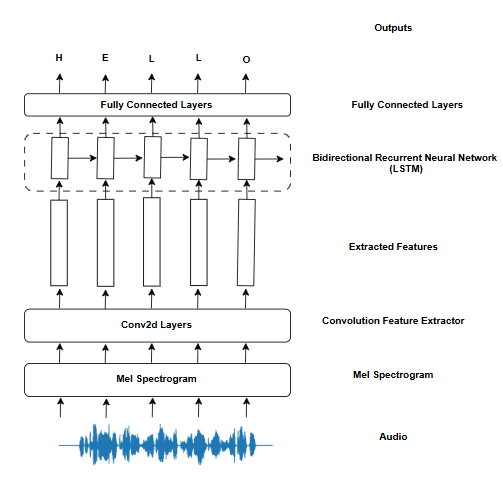

In [3]:
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("facebook/wav2vec2-base")
print(tokenizer.vocab) # 

{'<pad>': 0, '<s>': 1, '</s>': 2, '<unk>': 3, '|': 4, 'E': 5, 'T': 6, 'A': 7, 'O': 8, 'N': 9, 'I': 10, 'H': 11, 'S': 12, 'R': 13, 'D': 14, 'L': 15, 'U': 16, 'M': 17, 'W': 18, 'C': 19, 'F': 20, 'G': 21, 'Y': 22, 'P': 23, 'B': 24, 'V': 25, 'K': 26, "'": 27, 'X': 28, 'J': 29, 'Q': 30, 'Z': 31}


In [7]:
DATASET_ROOT = Path(LIBRISPEECH_DIR)
os.listdir(DATASET_ROOT)

['BOOKS.TXT',
 'CHAPTERS.TXT',
 'dev-clean',
 'LICENSE.TXT',
 'README.TXT',
 'SPEAKERS.TXT',
 'train-clean-100']

In [ ]:
# # file hiện tại
# CURRENT_FILE = Path.cwd().resolve()  #Path(__file__).resolve()

# # project root
# PROJECT_ROOT = CURRENT_FILE.parents[0]
# DATA_DIR = PROJECT_ROOT / "data"
# DATASET_CACHE = DATA_DIR / "dataset_cache"
# print(DATASET_CACHE)

C:\Users\HuyenDT\source\repos\sttproject\data\dataset_cache


In [8]:
# Load a sample and visualize
sampleset = LibrispeechDataset(DATASET_ROOT, include_splits = ["dev-clean"], is_from_cached = False)
#sampleset = dataset.librispeech.LibrispeechDataset(DATASET_ROOT, include_splits = ["dev-clean"], is_from_cached = True, cache_version=2, cached_path=DATASET_CACHE)
# sampleset = dataset.librispeech.LibrispeechDataset(DATASET_ROOT, include_splits = ["train-clean-100"], is_from_cached = True, cache_version=1)
sample =next(iter(sampleset))
print(len(sampleset))

2605


### An audio example  

Audio

In [12]:

file_index = 9
audio_path = sampleset.librispeech_data[file_index][0]
audio_transrcipt = sampleset.librispeech_data[file_index][1]

print(audio_transrcipt)

audio, sampling_rate = torchaudio.load(audio_path)
Audio(audio, rate=sampling_rate)

NEAR THE FIRE AND THE ORNAMENTS FRED BROUGHT HOME FROM INDIA ON THE MANTEL BOARD


Waveform

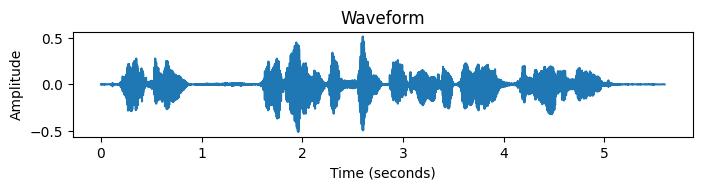

In [7]:
audio = audio.squeeze()

num_samples = len(audio)
time_axis = torch.arange(num_samples) / 16000

plt.figure(figsize=(8, 3))
plt.subplot(2, 1, 2)
plt.plot(time_axis, audio)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

Waveform with different time lengths

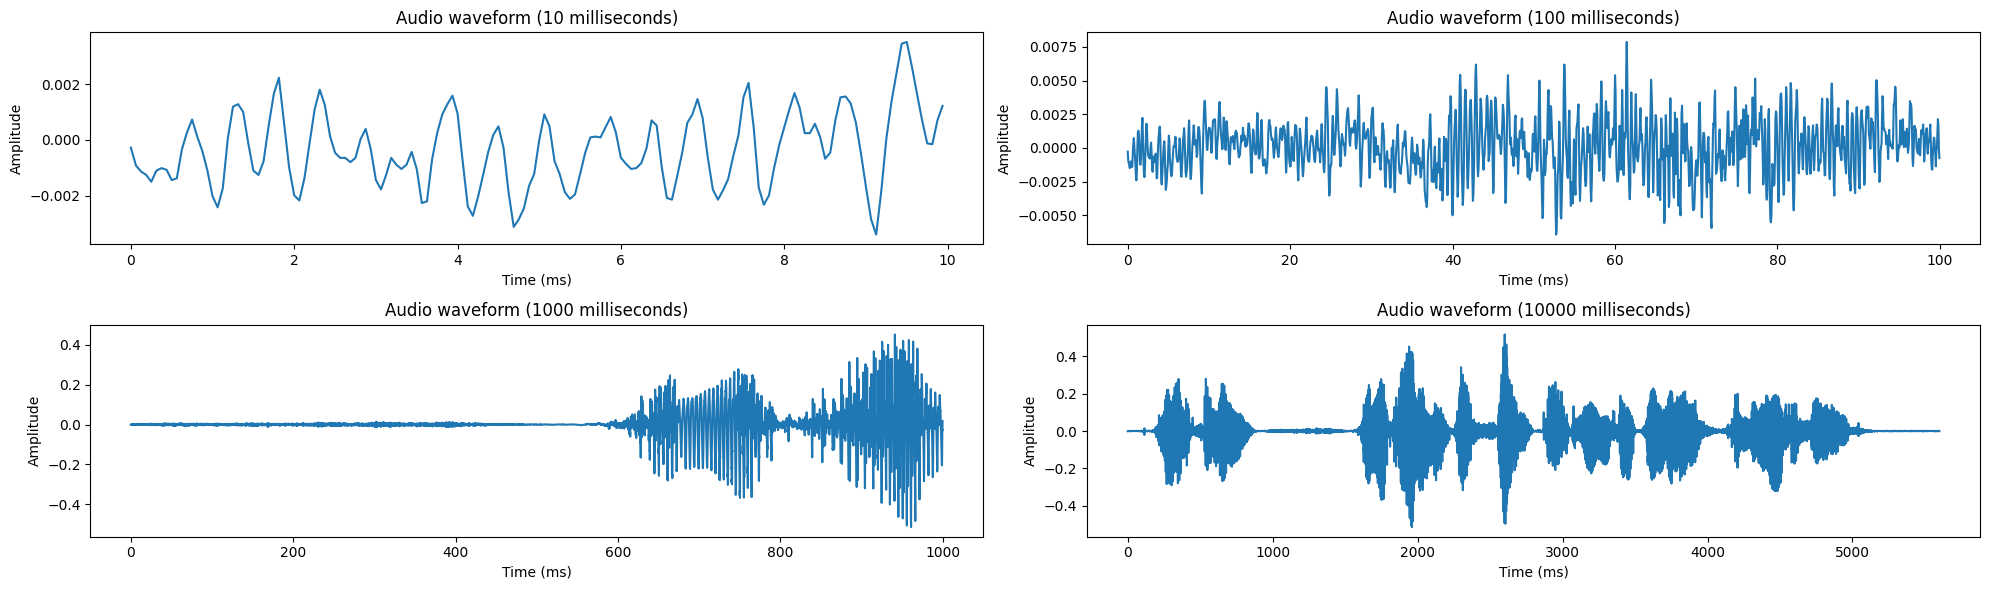

In [8]:
import matplotlib.pyplot as plt 

def drawWaveform (start_time_ms, audioLen, axes, sample_rate = 16000): 
    start_time_ms = start_time_ms 
    end_time_ms = start_time_ms + audioLen # milliseconds: 10, 100, 1000: this is how amplitude values look like for the next 10, 100... miliseconds

    start_idx = int(start_time_ms * sample_rate / 1000) # sample_rate/sec => need to divide by 1000
    end_idx = int(end_time_ms * sample_rate / 1000)

    audio_np = audio[start_idx: end_idx]

    # Create time axis in milliseconds
    time_ms = np.arange(len(audio_np)) * (1000/sample_rate)

    axes.plot(time_ms, audio_np)
    axes.set_xlabel('Time (ms)')
    axes.set_ylabel('Amplitude')
    axes.set_title(f"Audio waveform ({audioLen} milliseconds)")
    # plt.show()

fig, axes = plt.subplots(2, 2, figsize=(20, 6))
axes = axes.flatten() 

drawWaveform(1000, 10, axes[0]) 
drawWaveform(1000, 100, axes[1])
drawWaveform(1000, 1000, axes[2])
drawWaveform(0, 10000, axes[3])
plt.tight_layout()

Spectrogram

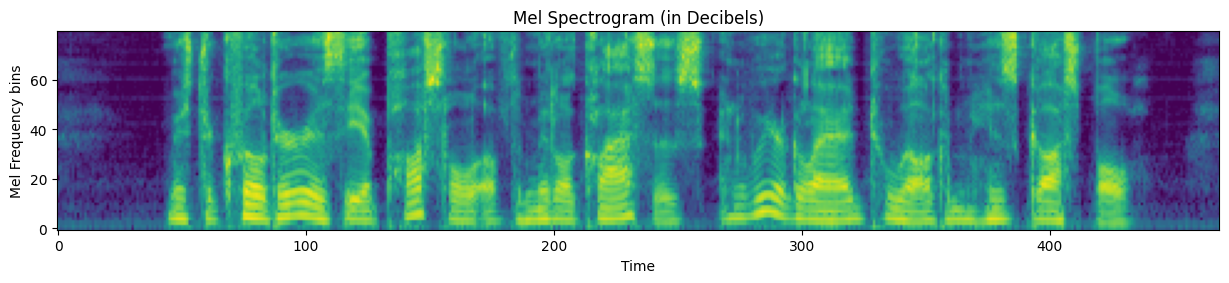

In [9]:
# visualize 
plt.figure(figsize=(15, 5))
plt.imshow(sample["input_values"].T)
# plt.axis("off")
plt.title('Mel Spectrogram (in Decibels)')
plt.ylabel('Mel Frequency bins')
plt.xlabel('Time')
plt.gca().invert_yaxis() # gca: Get Current Axes, (and flip so low frequencies are at the bottom)
plt.show()

### Collate Function 
- spectrograms: Pad spectrograms to longest in the batch and concatenate 
- seq_lens: just so we know the original size of each sample before we padded 
- packed_transcript: Packed Padding of Labels (CTC Loss can take a single vector of all target tokens across all samples in the batch)
- target_lengths: Because we concatenated all our labels into a single vector, CTC needs to know how mnay token go with each sample in the batch 

=> RNN in PyTorch can take Packed Padded data => only need to sort the seq lengths in the batch are longest to shortest 

Input Values: torch.Size([5, 1, 80, 999])
Seq Lens: tensor([999, 793, 721, 469, 386])
Labels: torch.Size([565])
Target Lengths: tensor([172, 133, 108,  89,  63])
OK, same length


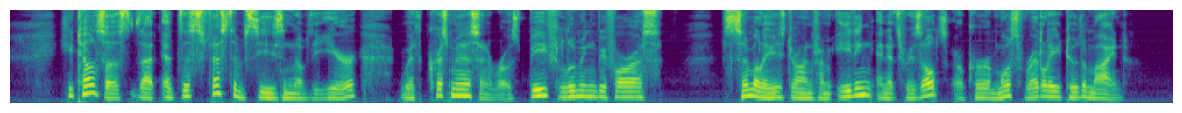

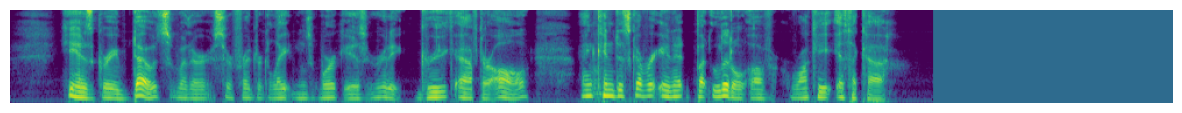

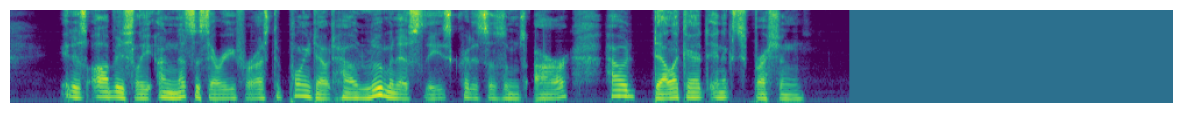

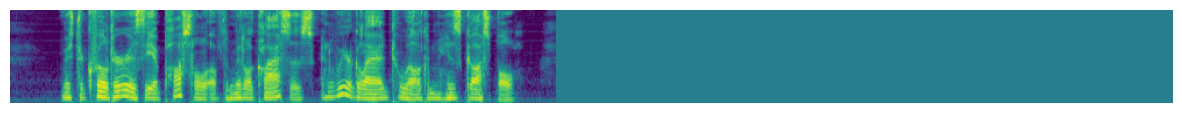

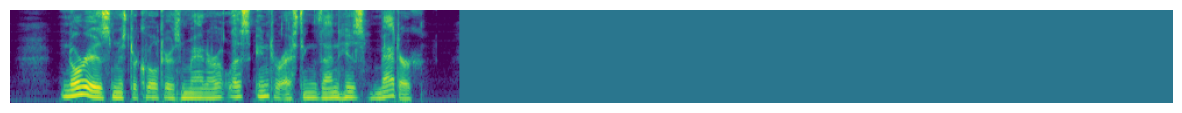

In [11]:
from src.dataset.librispeech import collate_fun

# test collate func 
loader = DataLoader(dataset=sampleset, batch_size=5, collate_fn=collate_fun)
batch = next(iter(loader))

print("Input Values:", batch["input_values"].shape)
print("Seq Lens:", batch["seq_lens"]) # the original length of each sample before padding
print("Labels:", batch["labels"].shape) # concat all labels together
print("Target Lengths:", batch["target_lengths"]) # how many labels are for first, second... samples

# as required by CTC loss, sum of the target lengths must equal the length127th of the flattened labels 
if batch["target_lengths"].sum() == len(batch["labels"]): 
    print("OK, same length")

for s in batch["input_values"]: 
    plt.figure(figsize=(15, 5))
    plt.imshow(s.squeeze()) # remove batch dim when decode a sample
    plt.axis("off")
    plt.gca().invert_yaxis() # gca: Get Current Axes
    plt.show()


In [13]:
batch["input_values"].shape 

torch.Size([5, 1, 80, 999])

### Masked Convolution

When doing convolutions on our samples, need to
- convolve on the spectrograms
- do padding 


### Adjust for Convolution Downsample
Convolution is 2d (its an image) so we will have a convolution in both the time dimension but also the feature (mel bins) dimension. We are not caring too much about the mel bins dimension right now (it's always 80 now), but the time dimension that can change. 

This means when we write things like our kernel size of (3,3), it is a kernel sie of 3 in the mel dimension and a kernal size of 3 in the time dimension. 

Similarity, if we write our convolution as (1, 2), we will have stride of 1 along the mel dimension, and then a stride of 2 along the time dimension 

In [12]:
# in_channels: 1 from the second dimension: batch["input_values"].shape [5, 1, 80, 853]
# out_channels = số filter bạn muốn học => how many features 
# kernel_size
# stride: Dùng để giảm chiều thời gian / freq, giống pooling
# stride(stride_height, stride_width) => stride(1,2): keep the freq the same, reduce half of time, down sampling by a factor of two
# => reduce time steps for RNN, save computation 

# padding=(pad_height, pad_width) : 1 => padding at the top & bottom, not horizontal => keep 80, 1: keep same, 0: padding 0 at this dimension
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=(3,3), stride=(1,2), padding=(1,0))

print(batch["input_values"].shape)
output = conv(batch["input_values"])
print(output.shape)

torch.Size([5, 1, 80, 999])
torch.Size([5, 1, 80, 499])


So we have downsampled out total batch length by a half, some of those timestamps were padding => now what parts of the downsampled signal came from padding, and what parts came from non-padding?  

You can see this in the [Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) docs from PyTorch! 

In [15]:
padding = 0 
kernel_size = 3 
stride = 2

print("Input Seq Lens:", batch["seq_lens"])
output_seq_lens = torch.floor((batch["seq_lens"] + (2 * padding) - (kernel_size -1) -1)//stride + 1)
print("Ouput Seq Lens:", output_seq_lens)
# the max length is: 426 (the first, lengthest item)
# the second item: only first 385 outputs are valid, from 385-> 426 is padded
# the third item...

Input Seq Lens: tensor([999, 793, 721, 469, 386])
Ouput Seq Lens: tensor([499, 396, 360, 234, 192])


### Masking the Output
We now know the output sequence length of every spectrogram, meaning any sequence length after those are not valid. 

We must remask them to 0 to help model not to calculate loss of them 

=> We create a new [0, 1] mask based on the output sequence lengths and multiply our data by it, zeroing out any non-valid convolutiona output coming from the padding regions 

In [16]:
output_seq_lens

tensor([499, 396, 360, 234, 192])

In [17]:
mask = torch.nn.utils.rnn.pad_sequence([torch.ones(i) for i in output_seq_lens], padding_value=0, batch_first=True)
mask 
# 426 items with value of 1
# 385 items with value of 1...

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.]])

In [18]:
print(mask.shape)
print(output.shape)

torch.Size([5, 499])
torch.Size([5, 1, 80, 499])


In [19]:
mask = mask.unsqueeze(1).unsqueeze(1) # unsqueeze = np.newaxis in numpy
print(mask.shape)
print(output.shape)

torch.Size([5, 1, 1, 499])
torch.Size([5, 1, 80, 499])


In [20]:
output = output * mask # *: (element-wise), @ : Matrix multiplication
print(output)

tensor([[[[0.7491, 0.4431, 0.2734,  ..., 0.5176, 0.5043, 0.6896],
          [0.4129, 0.3956, 0.3758,  ..., 0.3567, 0.2830, 0.3927],
          [0.4540, 0.5393, 0.4659,  ..., 0.4291, 0.3744, 0.4678],
          ...,
          [0.7826, 0.9052, 0.9208,  ..., 0.8260, 0.8260, 0.8260],
          [0.8372, 0.8617, 0.8300,  ..., 0.8260, 0.8260, 0.8260],
          [1.3599, 1.3127, 1.0992,  ..., 1.3740, 1.3740, 1.3740]]],


        [[[0.7189, 0.6623, 0.7234,  ..., 0.0000, 0.0000, 0.0000],
          [0.5787, 0.2740, 0.3950,  ..., 0.0000, 0.0000, 0.0000],
          [0.3630, 0.3297, 0.3743,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.7826, 0.8011, 0.7427,  ..., 0.0000, 0.0000, 0.0000],
          [0.7825, 0.7829, 0.8187,  ..., 0.0000, 0.0000, 0.0000],
          [1.2887, 1.2866, 1.2800,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.5038, 0.6127, 0.6094,  ..., 0.0000, 0.0000, 0.0000],
          [0.2807, 0.2610, 0.3371,  ..., 0.0000, 0.0000, 0.0000],
          [0.3889, 0.2591, 0.3383,  ..

### Create the Masked Conv2d 
create a wrapper on the existing convolution 

In [13]:
from shared.models import MaskedConvd2d

### Convolutional Feature Extractor 

Learn features from both strong and weak frequency patterns of spectrogram 

Create a stack of two convolutions with BatchNorm2d and the HardTanh Activation function 

The output of the convolutions will give the shape (Batch x Channels X Mel_features x time). To give this to the future RNN, we need to reshape it to (Batch x time x Channels * Mel_features)

from (B, C, H, W) => (B, C, H*W) ~ (B, embedding, tokens)
=> need to this format: (B, tokens, embedding)

ex: input shape: (batch_size, features)
- BatchNorm: normalize by dimension 0 (batch) 
    - compares each sample to others in the same batch
    - batch size is big enough (>= 16)
    - CNN
- LayerNorm: normalize by dimension 1 (features)
    - compares features inside the same sample
    - small batch size 
    - NLP, TRansformer, RNN

In [14]:
from shared.models import ConvolutionFeatureExtractor

c = ConvolutionFeatureExtractor()
c(batch["input_values"], batch["seq_lens"])

(tensor([[[ 5.8646e-01,  1.0000e+00,  1.0000e+00,  ...,  1.0000e+00,
            1.0000e+00,  1.0000e+00],
          [ 7.7729e-01,  5.7861e-01,  1.0000e+00,  ...,  9.2054e-01,
           -1.1290e-02, -1.5999e-01],
          [ 5.2356e-01,  1.0000e+00,  1.0000e+00,  ..., -6.0294e-02,
           -8.1315e-01, -1.0000e+00],
          ...,
          [-6.1043e-01, -4.5141e-01, -8.7306e-01,  ..., -1.0000e+00,
           -1.0000e+00, -4.9553e-01],
          [ 4.7241e-01, -3.1793e-01, -1.5822e-01,  ..., -6.8752e-01,
           -1.0000e+00, -3.6384e-01],
          [ 2.3219e-01,  2.4520e-01,  4.8069e-01,  ..., -1.9492e-01,
           -6.3419e-01, -1.7396e-01]],
 
         [[ 6.9690e-01,  1.0000e+00,  1.0000e+00,  ...,  1.0000e+00,
            1.0000e+00,  1.0000e+00],
          [ 5.0052e-01,  1.0000e+00,  1.0000e+00,  ...,  1.0000e+00,
           -8.6545e-03,  1.0000e+00],
          [ 8.6980e-01,  8.6320e-01,  1.0000e+00,  ..., -3.5907e-01,
           -9.5046e-01,  5.0837e-02],
          ...,
    

After applying convolution 1:
- the same number of batch 
- from 1 channel => 32 channels
- 80 mel bins => 40 mel bins
- downsampled from 853 to 427 

After applying convolution 2:
- the same number of batch 
- from 1 channel => 32 channels
- 40 mel bins => 20 mel bins


### RNN Layer 

This is a Bidirectional RNN (can look both ways)

In [15]:
conv = ConvolutionFeatureExtractor()
conv_out, out_seq_lens = conv(batch["input_values"], batch["seq_lens"])
print(conv_out.shape) # [batch_size, time_steps, embeddings]
print(out_seq_lens) 

torch.Size([5, 500, 640])
tensor([500, 397, 361, 235, 193])


**Packed Padding**

Removes the padding tokens
- pack_padded_sequence: convert padded_sequence tensor into PackedSequence to RNN 
- pad_packed_sequence: convert PackedSequence back to tensor padded

In [16]:
packed_conv_out = nn.utils.rnn.pack_padded_sequence(conv_out, out_seq_lens, batch_first=True) # batch_first: the first dimension is batch_size
print(packed_conv_out)
# packed_conv_out.data: all concatenated together, no padding 
# packed_conv_out.batch_sizes: batch_sizes[i] is the number of sequences that still have valid data at timestep i
# timestemp[0]: 5 sequences are valid .... timetemp[147]: 5
# timestemp[148]: only 4 are valid....
# => which indixes are valid at the diff samples 

PackedSequence(data=tensor([[ 0.3127,  0.5246,  0.0251,  ...,  0.3818,  0.6117, -0.0237],
        [ 0.7680,  0.3820,  0.4544,  ...,  0.0118,  0.3602, -0.2160],
        [ 1.0000, -0.0993,  0.8881,  ...,  0.2701,  0.0732, -0.2859],
        ...,
        [-0.3245,  0.2853,  0.6392,  ..., -1.0000, -1.0000, -1.0000],
        [-0.5737,  0.2409,  0.6526,  ..., -1.0000, -1.0000, -1.0000],
        [-0.9286, -0.2765,  0.2164,  ..., -1.0000, -1.0000, -1.0000]],
       grad_fn=<PackPaddedSequenceBackward0>), batch_sizes=tensor([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       

In [25]:
packed_conv_out.batch_sizes.shape # max out_seq_lens of batch 

torch.Size([500])

In [26]:
print(out_seq_lens)
torch.unique(packed_conv_out.batch_sizes, return_counts=True) # len = 427 
# => after 147 times of 5 
# => 2 = (149-147) times of 4, 
# => 197 = (346 - 149) times of 3 ....

tensor([500, 397, 361, 235, 193])


(tensor([1, 2, 3, 4, 5]), tensor([103,  36, 126,  42, 193]))

In [27]:
rnn = nn.GRU( # Long Short-Term Memory
            input_size = 640, # no of features at each timestep 
            hidden_size=512, # no dof neuron at hidden state 
            batch_first=True, 
            bidirectional=True, # when training the rnn, future steps can look in the past steps and vice versa as the entire input is passed at once
            dropout=0.3
        )


In [28]:
out, _ = rnn(packed_conv_out)

In [29]:
x, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True )
x.shape

torch.Size([5, 500, 1024])

In [17]:
from shared.models import RNNLayer

### Put it together 

Put it all together to create our DeepSpeech2 model 

In [18]:
from shared.models import DeepSpeech2

model = DeepSpeech2()
model

DeepSpeech2(
  (feature_extractor): ConvolutionFeatureExtractor(
    (conv1): MaskedConvd2d(1, 32, kernel_size=(11, 41), stride=(2, 2), padding=(5, 20), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): MaskedConvd2d(32, 32, kernel_size=(11, 21), stride=(2, 1), padding=(5, 10), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (rnns): ModuleList(
    (0): RNNLayer(
      (rnn): LSTM(640, 512, batch_first=True, dropout=0.3, bidirectional=True)
      (layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (1-4): 4 x RNNLayer(
      (rnn): LSTM(1024, 512, batch_first=True, dropout=0.3, bidirectional=True)
      (layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
  )
  (head): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): Hardtanh(min_val=-1.0, max_val=1.0)
    (2): Linear(in_features=5

In [19]:
### Training agurments 
BATCH_SIZE = 32
TRAINING_ITERATIONS = 1000 # 50000 # how many iterations 
EVAL_ITERATIONS = TRAINING_ITERATIONS//5  # 2500 (//20.0 ) # How often want to evaluate a learning reate 
LEARNING_RATE = 1e-4 # 10^(-4)
NUM_WORKERS = 0 # to do stuff parallel => can be the number of CPU (if has data preload => set NUM_WORKERS = 0), but in notebooks only can run with NUM_WORKERS = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WARMUPS_STEPS = np.floor(0.01 * TRAINING_ITERATIONS) # get 1% of trainining steps to increase LEARNING_RATE from 0 to LEARNING_RATE

In [33]:
TRAINING_ITERATIONS,EVAL_ITERATIONS, NUM_WARMUPS_STEPS

(1000, 200, np.float64(10.0))

In [23]:
### Data loaders ###
trainset = LibrispeechDataset(path_to_data_root=DATASET_ROOT, include_splits=["train-clean-100"], is_augment = True, is_from_cached = False)
testset = LibrispeechDataset(path_to_data_root=DATASET_ROOT, include_splits=["dev-clean"], is_from_cached = False)
#trainset = LibrispeechDataset(path_to_data_root=DATASET_ROOT, include_splits=["train-clean-100"], is_from_cached = False, cache_version=1, cached_path=DATASET_CACHE)
#sampleset = LibrispeechDataset(path_to_data_root=DATASET_ROOT, include_splits=["dev-clean"], is_from_cached = False, cache_version=2, cached_path=DATASET_CACHE)

In [ ]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fun, num_workers=NUM_WORKERS)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fun, num_workers=NUM_WORKERS) # , persistent_workers=True when set multiple workers

### Define the model ###
model = DeepSpeech2(conv_in_channels=1, 
                    conv_out_channels=32,
                    rnn_hidden_size= 128,  #512
                    rnn_depth = 2 # 5 
                    ).to(DEVICE)

# numel: number of elements
params = sum([p.numel() for p in model.parameters()])
print("Total training Parameter: ", params)

### Optimizer ###
optimizer = optim.AdamW(params=model.parameters(), lr=LEARNING_RATE) # weight_decay=0.01 (≈ L2 regularization)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=NUM_WARMUPS_STEPS, num_training_steps=TRAINING_ITERATIONS)
# get_cosine_schedule_with_warmup:
# 1. warmup: in num_warmup_steps first steps: increase learning rate from 0 to LEARNING_RATE (avoid big gradient at first steps => help model learn more stably)
# 2. Cosine decay: after warmup, decrease learning rate by cosine until the end of training: until TRAINING_ITERATIONS (decrese lr smoothly => help the model be converged better)

Total training Parameter:  1472896


In [ ]:
model.load_state_dict(torch.load("best_weights.pt",weights_only=True)) # best_weights_512_3rnn, best_weights_128_2rnn

<All keys matched successfully>

In [ ]:
best_val_loss = np.inf 
train = True 
completed_steps = 0 
train_his_loss, validation_his_loss = [], []
pbar = tqdm(range(TRAINING_ITERATIONS))

while train: 
    batch_training_loss = []
    batch_validation_loss = []

    for batch in trainloader: 
        # print(batch)
        # input_lengths: seq_lens after conv layer: where is actual input, where is padding 
        logits, input_lengths = model(batch["input_values"].to(DEVICE), batch["seq_lens"])
        
        #print(logits.shape)
        #print(input_lengths)

        log_probs = nn.functional.log_softmax(logits, dim=-1) # dim=-1: apply softmax for the last dimension [batch_size, num_classes],
        #print(log_probs.shape) # => [batch_size, seq_lens, num_classes]
        log_probs = log_probs.transpose(0,1) # but CTC expect: [Time, batch_size, num_classes] => need to transpose two first dimensions

        # print(len(batch["labels"]), sum(batch["target_lengths"])) # the same number 

        loss = nn.functional.ctc_loss(
            log_probs=log_probs,
            targets=batch["labels"].to(DEVICE),
            input_lengths=input_lengths, 
            target_lengths=batch['target_lengths'].to(DEVICE),
            blank=tokenizer.pad_token_id, 
            reduction="mean" # "mean" → mean on batch, "sum" → 1 scalar = sum loss of batch, "none" → each sample has seperate loss 
        )

        # print(loss)

        loss.backward() # backpropagation
        optimizer.step() # update weights
        optimizer.zero_grad(set_to_none=True) # reset gradients of previous batch, which does not have effect to the next batch
        scheduler.step() # update learning rate 

        batch_training_loss.append(loss.item())
        completed_steps += 1 
        pbar.update(1)

        if completed_steps % EVAL_ITERATIONS == 0: 
            print("Evaluating...")
            model.eval() # set model to evaluation mode 

            for batch in tqdm(testloader): 
                ### Pass through model and get input_lengths (pocst convolutions) and logits ###
                with torch.no_grad(): # tells PyTorch to not calculate the gradients in this block 
                    logits, input_lengths = model(x=batch["input_values"].to(DEVICE), seq_lens=batch["seq_lens"])

                    #CTC expects log probabilities 
                    log_probs = nn.functional.log_softmax(logits, dim=-1)

                    # CTC also expects (TxBxC), we have (BxTxC)
                    log_probs = log_probs.transpose(0,1)

                    # Compute CTC loss 
                    loss = nn.functional.ctc_loss(
                        log_probs=log_probs,
                        targets=batch["labels"].to(DEVICE),
                        input_lengths=input_lengths, 
                        target_lengths=batch['target_lengths'].to(DEVICE),
                        blank=tokenizer.pad_token_id, 
                        reduction="mean"
                    )

                    # Store Loss for this batch 
                    batch_validation_loss.append(loss.item())
            
            # calculate epoch loss = np.mean of all batches 
            epoch_training_loss_mean = np.mean(batch_training_loss)
            epoch_valid_loss_mean = np.mean(batch_validation_loss)

            # log to hist
            train_his_loss.append(epoch_training_loss_mean)
            validation_his_loss.append(epoch_valid_loss_mean)
    
            print("Training Loss:", epoch_training_loss_mean)
            print("Validation Loss:", epoch_valid_loss_mean)

            # Rest list 
            batch_training_loss = []
            batch_validation_loss = []

            # Save model if val loss decreases 
            if epoch_valid_loss_mean < best_val_loss:
                print("---Saving model---")
                torch.save(model.state_dict(), "../saved_models/best_weights.pt")
                # torch.save({
                #     'epoch': completed_steps,
                #     'model_state_dict': model.state_dict(),
                #     'optimizer_state_dict': optimizer.state_dict(),
                # }, "checkpoint.pt")
                                
                best_val_loss = epoch_valid_loss_mean

            # Set Model to Training mode
            model.train() 

        if completed_steps >= TRAINING_ITERATIONS: 
            train = False 
            print("Completed!")
            break

 20%|██        | 200/1000 [1:50:23<7:10:06, 32.26s/it]

Evaluating...


100%|██████████| 85/85 [10:55<00:00,  7.71s/it]


Training Loss: 1.8004764610528945
Validation Loss: 1.6471967655069688
---Saving model---


 40%|████      | 400/1000 [3:49:50<5:30:08, 33.01s/it]  

...

Training Loss: 1.6589684617519378
Validation Loss: 1.5639680175220265
---Saving model---


100%|██████████| 1000/1000 [9:45:09<00:00, 28.36s/it]   

Evaluating...


100%|██████████| 85/85 [09:09<00:00,  6.46s/it]

Training Loss: 1.6384347401283406
Validation Loss: 1.5591314484091365
---Saving model---
Completed!


### Training Results

In [27]:
train_his_loss = torch.load(SAVED_MODELS_DIR / "train_his_loss.pt", weights_only=False)
validation_his_loss = torch.load(SAVED_MODELS_DIR / "validation_his_loss.pt", weights_only=False)
train_his_loss

[np.float64(1.3809041914939881),
 np.float64(1.2777527612447739),
 np.float64(1.2096725759506226),
 np.float64(1.169940080523491),
 np.float64(1.1397800505640678),
 np.float64(1.122083104789257),
 np.float64(1.112217484652996)]

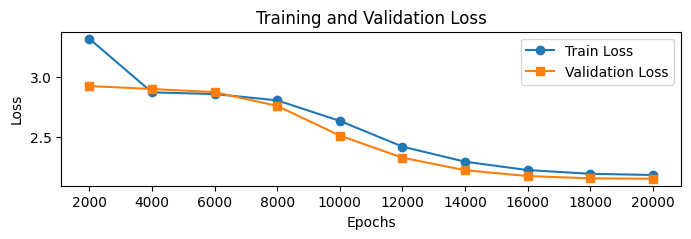

In [ ]:
epochs = range(1, len(train_his_loss) + 1) 
epochs = [a*2000 for a in epochs]
# wers = [0.88, 0.83 , 0.81,0.79, 0.78, 0.77, 1, 1, 1, 1]
# epochs= torch.arange(train_his_loss) *10

plt.figure(figsize=(8, 2))
plt.plot(epochs, train_his_loss, label="Train Loss", marker='o')
plt.plot(epochs , validation_his_loss, label="Validation Loss", marker='s')
# plt.plot(epochs , wers, label="WER", marker='s')

plt.xticks(epochs)  # custom labels

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
epochs

range(1, 11)

### Load Best Checkpoint

In [72]:
model = DeepSpeech2(rnn_hidden_size= 128,  #512
                    rnn_depth = 2 )
model.load_state_dict(torch.load(SAVED_MODELS_DIR / "best_weights.pt", weights_only=True)) # best_weights_512_3rnn, best_weights_128_2rnn
model.eval() # switch from training mode to eval

DeepSpeech2(
  (feature_extractor): ConvolutionFeatureExtractor(
    (conv1): MaskedConvd2d(1, 32, kernel_size=(11, 41), stride=(2, 2), padding=(5, 20), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): MaskedConvd2d(32, 32, kernel_size=(11, 21), stride=(2, 1), padding=(5, 10), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (rnns): ModuleList(
    (0): RNNLayer(
      (rnn): LSTM(640, 128, batch_first=True, dropout=0.3, bidirectional=True)
      (layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (1): RNNLayer(
      (rnn): LSTM(256, 128, batch_first=True, dropout=0.3, bidirectional=True)
      (layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (head): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Hardtanh(min_val=-1.0, max_val=1.0)
    (2): Linear(in_features=128, out_fe

### Inference Audio

In [76]:
import src.inference as inf_module
importlib.reload(inf_module)
from src.inference import inference

In [31]:
checkpoint = torch.load(SAVED_MODELS_DIR / "checkpoint.pt", weights_only =False)
checkpoint["epoch"]

18000

### Inference by the audio path

In [84]:
TEST_INDEX = 0
path_to_sample, transcript = sampleset.librispeech_data[TEST_INDEX]
pred_transcript = inference(path_to_sample, model, tokenizer)

print(f"Transcript: {transcript}")
print(f"Predicted: {pred_transcript}")
error = wer(transcript, pred_transcript)
print(f"Word Error Rate: {error}")

audio, sampling_rate = torchaudio.load(path_to_sample)
Audio(audio, rate=sampling_rate)

Transcript: MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
Predicted: HIS TE CULDER AS THE A PLEOE OF TE MILE CLASSES ANDWEARE GLAD TILAN HIS GOSPL
Word Error Rate: 0.8235294117647058


### Word Error Rate
$$
WER = \frac{S+D+I}{N}
$$
- S: Substitution
- D: Deletion
- I: Insertion
- N: Numer of words in ground truth

ex: 
|  | 1 |2  |3 | 4|
|-----------|-----------|-----------|-----------|-----------|
|  **Ground truth:**| I | love |machine |learning |
| **Prediction:** | I | like |machine |learning |
| **Check WER:** |  | S | | |

=> S:1, D:0, I:0, N: 4 => WER = (1 + 0 + 0)/4 = 0.25


In [ ]:
transcripts =[]
pred_transcripts = []
for path_to_sample, transcript in tqdm(sampleset.librispeech_data): 
    transcripts.append(transcript)
    pred_transcripts.append(inference(path_to_sample, model, tokenizer))

overallError = wer(transcripts, pred_transcripts)
print(f"Overall Word Error Rate: {overallError}")

100%|██████████| 2605/2605 [13:43<00:00,  3.16it/s] 


Overall Word Error Rate: 0.7656079078740627


In [ ]:
out = process_words(transcripts, pred_transcripts)

print(f"Substitutions: {out.substitutions}")
print(f"Deletions: {out.deletions}")
print(f"Insertions: {out.insertions}")
print(f"Hits: {out.hits}") # correct words
print(f"Wer: {out.wer}") # out.alignments # references

Substitutions: 32489
Deletions: 3729
Insertions: 2276
Hits: 14061
Wer: 0.7656079078740627


### Other Models

### Whisper

In [33]:
import whisper # OpenAI
whisper_model = whisper.load_model("tiny")

In [40]:
TEST_INDEX = 0
path_to_sample, transcript = sampleset.librispeech_data[TEST_INDEX]
waveform, orig_sr = torchaudio.load(path_to_sample, normalize=True)
pred_transcript = whisper_model.transcribe(waveform.flatten())["text"]

transcript = normalize(transcript)
pred_transcript= normalize(pred_transcript)

print(f"Transcript: {transcript}")
print(f"Predicted: {pred_transcript}")
error = wer(transcript, pred_transcript) # remove punctuation for fair comparison, because our model does not predict punctuation
print(f"Word Error Rate: {error}") # it has punctuation marks, so the WER is higher than our model, but it can predict punctuation, which is a plus point

audio, sampling_rate = torchaudio.load(path_to_sample)
Audio(audio, rate=sampling_rate)

Transcript: mister quilter is the apostle of the middle classes and we are glad to welcome his gospel
Predicted:  mr quilter is the apostle of the middle classes and we are glad to welcome his gospel
Word Error Rate: 0.058823529411764705


### Wav2Vec2

In [4]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

model_name = "facebook/wav2vec2-large-960h"

processor = Wav2Vec2Processor.from_pretrained(model_name) # wav2vec2-large/base-960h
model = Wav2Vec2ForCTC.from_pretrained(model_name)

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
TEST_INDEX = 0
path_to_sample, transcript = sampleset.librispeech_data[TEST_INDEX]
waveform, orig_sr = torchaudio.load(path_to_sample, normalize=True)
inputs = processor(
        waveform.squeeze().numpy(),
        sampling_rate=16000,
        return_tensors="pt",
        padding=True,
    )
with torch.no_grad():
    logits = model(**inputs).logits
ids = torch.argmax(logits, dim=-1)
pred_transcript= processor.batch_decode(ids)[0]

transcript = normalize(transcript)
pred_transcript= normalize(pred_transcript)

print(f"Transcript: {transcript}")
print(f"Predicted: {pred_transcript}")
error = wer(transcript, pred_transcript) # remove punctuation for fair comparison, because our model does not predict punctuation
print(f"Word Error Rate: {error}") # it has punctuation marks, so the WER is higher than our model, but it can predict punctuation, which is a plus point

audio, sampling_rate = torchaudio.load(path_to_sample)
Audio(audio, rate=sampling_rate)


Transcript: mister quilter is the apostle of the middle classes and we are glad to welcome his gospel
Predicted: mister quilter is the apostle of the middle classes and we are glad to welcome his gospel
Word Error Rate: 0.0


### Wav2Vec2 - Finnish

In [ ]:
model_name = "facebook/wav2vec2-large-xlsr-53"

model = Wav2Vec2ForCTC.from_pretrained(model_name)
processor = Wav2Vec2Processor.from_pretrained(model_name) # wav2vec2-large/base-960h


Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-large-xlsr-53 and are newly initialized: ['lm_head.bias', 'lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: expected str, bytes or os.PathLike object, not NoneType

: 